i. Importing libraries

In [16]:
import time
import re, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub

from sklearn.model_selection      import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing        import StandardScaler, RobustScaler
from sklearn.neighbors            import KNeighborsClassifier
from sklearn.tree                 import DecisionTreeClassifier
from sklearn.linear_model         import LogisticRegression
from sklearn.naive_bayes          import GaussianNB
from sklearn.neural_network       import MLPClassifier
from sklearn.cluster              import KMeans
from sklearn.decomposition        import PCA
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics              import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, adjusted_rand_score
)
from imblearn.pipeline  import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble  import BalancedRandomForestClassifier

!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

ii. Dataset loading

ii. a. Capturing dataset path

In [17]:
path = kagglehub.dataset_download("hopesb/student-depression-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-dataset' dataset.
Path to dataset files: /kaggle/input/student-depression-dataset


ii. b. Reading the dataset and storing copy

In [18]:
df = pd.read_csv("/kaggle/input/student-depression-dataset/Student Depression Dataset.csv")
df_copy = df.copy()
# df.columns
df.head(5)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


iii. Dataset Description

iii. a. Basic Statistics

In [19]:
print('=' * 60)
print('                      DATASET OVERVIEW')
print('=' * 60)
print(f'Total rows    : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')
print(f'\nThis is a CLASSIFICATION problem because the target\nvariable (Depression) is categorical: 1 for Depressed / 0 for Not Depressed.')
print(f'There is no continuous output to predict, so regression does not apply.\n')

quant_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols   = df.select_dtypes(include=['object']).columns.tolist()
print(f'Quantitative features ({len(quant_cols)}): {quant_cols}')
print(f'\nCategorical features  ({len(cat_cols)}): {cat_cols}')
print(f'\nMissing values:')
miss = df.isnull().sum()
print(miss[miss > 0])
# df.info()
# display(df.describe())
print(f'Defaults (Depressed)      : {df["Depression"].sum()} ({df["Depression"].mean()*100:.1f}%)')
print(f'Not Depressed             : {(df["Depression"]==0).sum()} ({(df["Depression"]==0).mean()*100:.1f}%)')

                      DATASET OVERVIEW
Total rows    : 27901
Total columns : 18

This is a CLASSIFICATION problem because the target
variable (Depression) is categorical: 1 for Depressed / 0 for Not Depressed.
There is no continuous output to predict, so regression does not apply.

Quantitative features (10): ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

Categorical features  (8): ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

Missing values:
Financial Stress    3
dtype: int64
Defaults (Depressed)      : 16336 (58.5%)
Not Depressed             : 11565 (41.5%)


iii. b. Correlation Heatmap

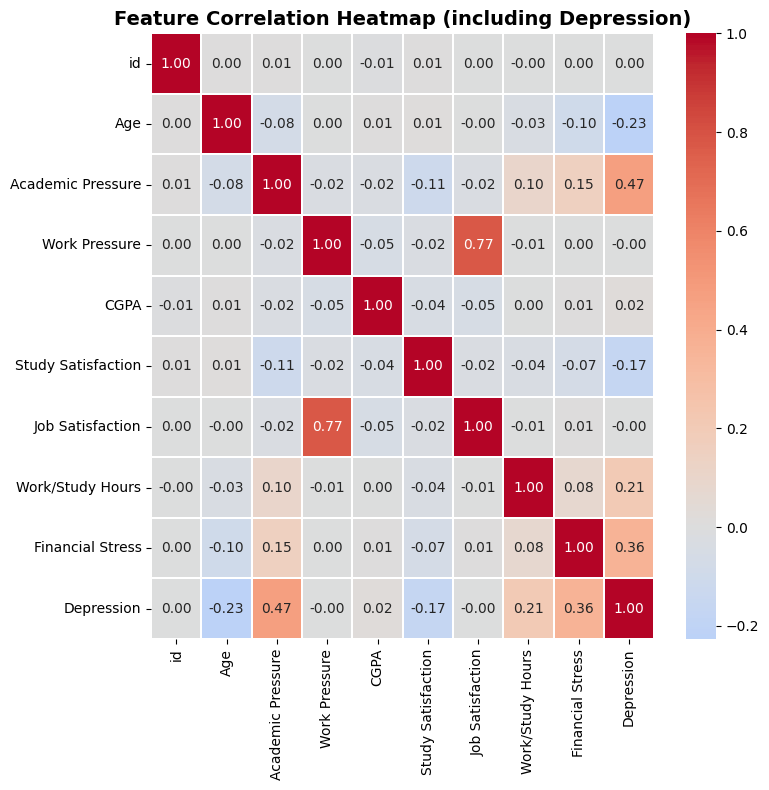

Top 9 features most correlated with Depression:
Academic Pressure     0.474835
Financial Stress      0.363591
Age                   0.226422
Work/Study Hours      0.208563
Study Satisfaction    0.167971
CGPA                  0.022210
Job Satisfaction      0.003482
Work Pressure         0.003351
id                    0.000923
Name: Depression, dtype: float64


In [20]:
num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.3, center=0, xticklabels=True, yticklabels=True, fmt=".2f")
plt.title('Feature Correlation Heatmap (including Depression)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

label_corr = corr['Depression'].drop('Depression').abs().sort_values(ascending=False)
print('Top 9 features most correlated with Depression:')
print(label_corr.head(10))

iii. c. Class imbalance bar chart

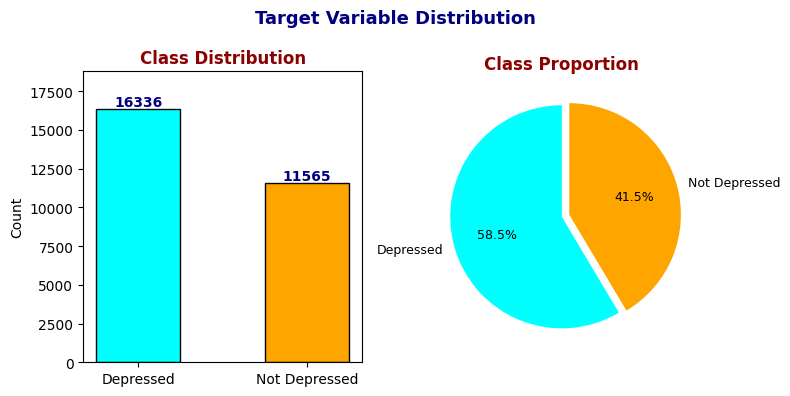


Imbalance Ratio: 1.41:1


In [21]:
counts = df['Depression'].value_counts().rename({0: 'Not Depressed', 1: 'Depressed'})
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

bars = axes[0].bar(counts.index, counts.values, color=['cyan', 'orange'], edgecolor='black', width=0.5)
axes[0].bar_label(bars, fontsize=10, fontweight='bold', color='navy')
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold', color='darkred')
axes[0].set_ylabel('Count', color='black')
axes[0].set_ylim(0, max(counts.values) * 1.15)

axes[1].pie(counts.values, labels=counts.index, colors=['cyan', 'orange'], autopct='%1.1f%%', startangle=90, explode=(0, 0.07), textprops={'color': 'black', 'fontsize': 9})
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold', color='darkred')
plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold', color='navy')

plt.tight_layout()
plt.show()
print(f"\nImbalance Ratio: {counts.max()/counts.min():.2f}:1")

The number of depressed students is higher than the numbers of not depressed students, thus the dataset is moderately imbalanced. So, stratification needs to be applied on train and test dataset and SMOTE is used inside each training pipeline to avoid data leakage

iii. d. Exploratory Data Analysis (EDA) for quantitative features

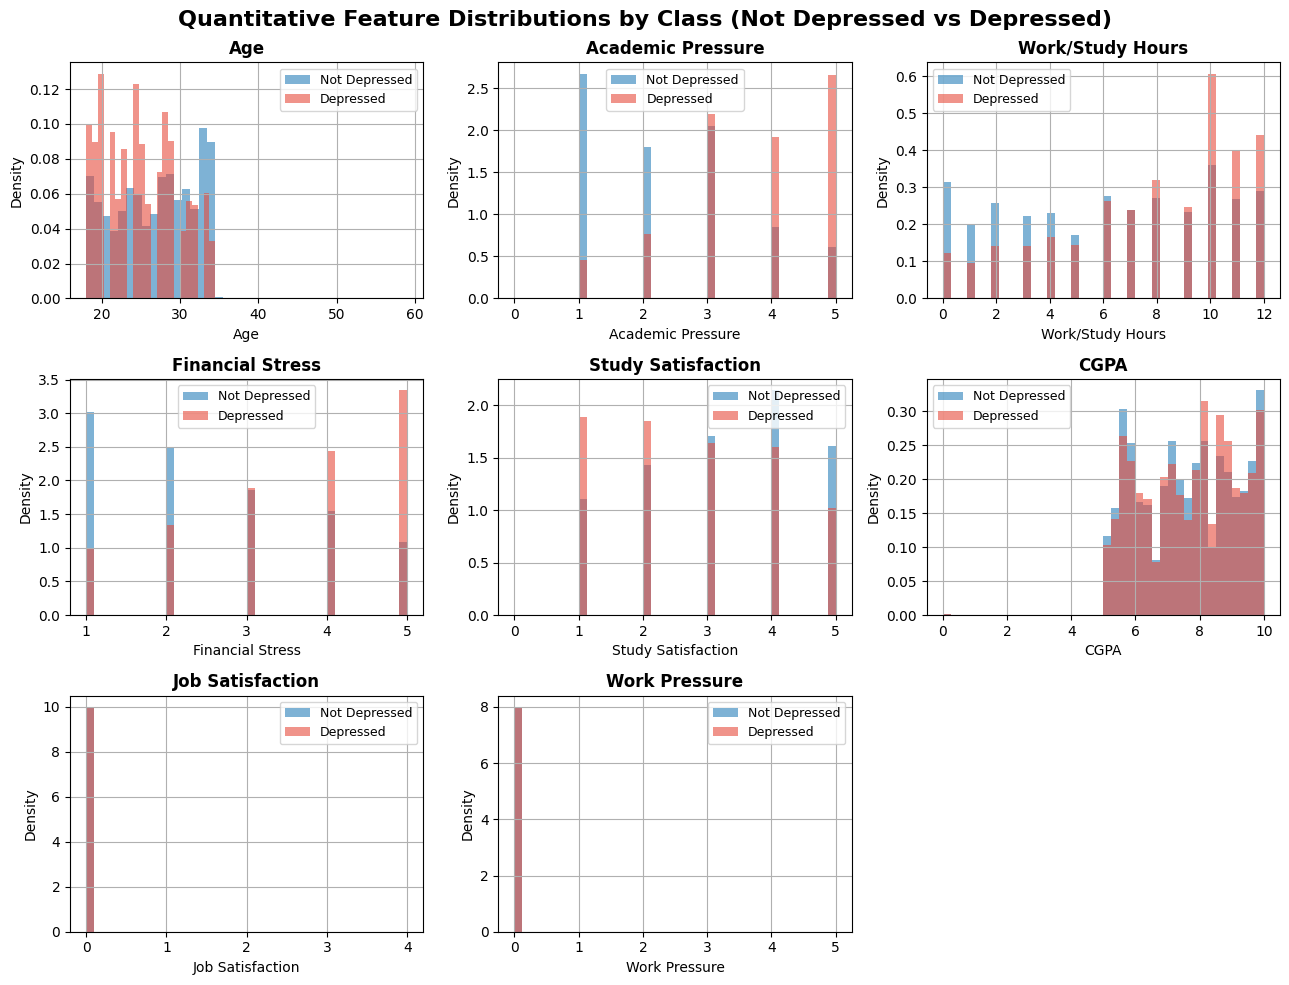

In [22]:
key_num = ['Age', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Study Satisfaction', 'CGPA', 'Job Satisfaction', 'Work Pressure']
n_cols = 3
n_rows = (len(key_num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_num):
    ax = axes[idx]
    df[df['Depression'] == 0][feat].dropna().hist(ax=ax, bins=40, alpha=0.6,
        color='#2980b9', label='Not Depressed', density=True)

    df[df['Depression'] == 1][feat].dropna().hist(ax=ax, bins=40, alpha=0.6,
        color='#e74c3c', label='Depressed', density=True)

    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

for i in range(len(key_num), len(axes)):
    axes[i].axis('off')

plt.suptitle('Quantitative Feature Distributions by Class (Not Depressed vs Depressed)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

iii. e. Skewness in numerical features

In [23]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in num_features: num_features.remove('id')

skewness_vals = df[num_features].skew().sort_values(ascending=False)

print('='*40)
print('      SKEWNESS OF NUMERICAL FEATURES')
print('='*40)
print(skewness_vals)

      SKEWNESS OF NUMERICAL FEATURES
Work Pressure         108.594361
Job Satisfaction       74.105663
Age                     0.132239
Study Satisfaction      0.010423
CGPA                   -0.113063
Financial Stress       -0.130304
Academic Pressure      -0.135165
Depression             -0.347126
Work/Study Hours       -0.454769
dtype: float64


iii. f. Exploratory Data Analysis (EDA) for categorical features

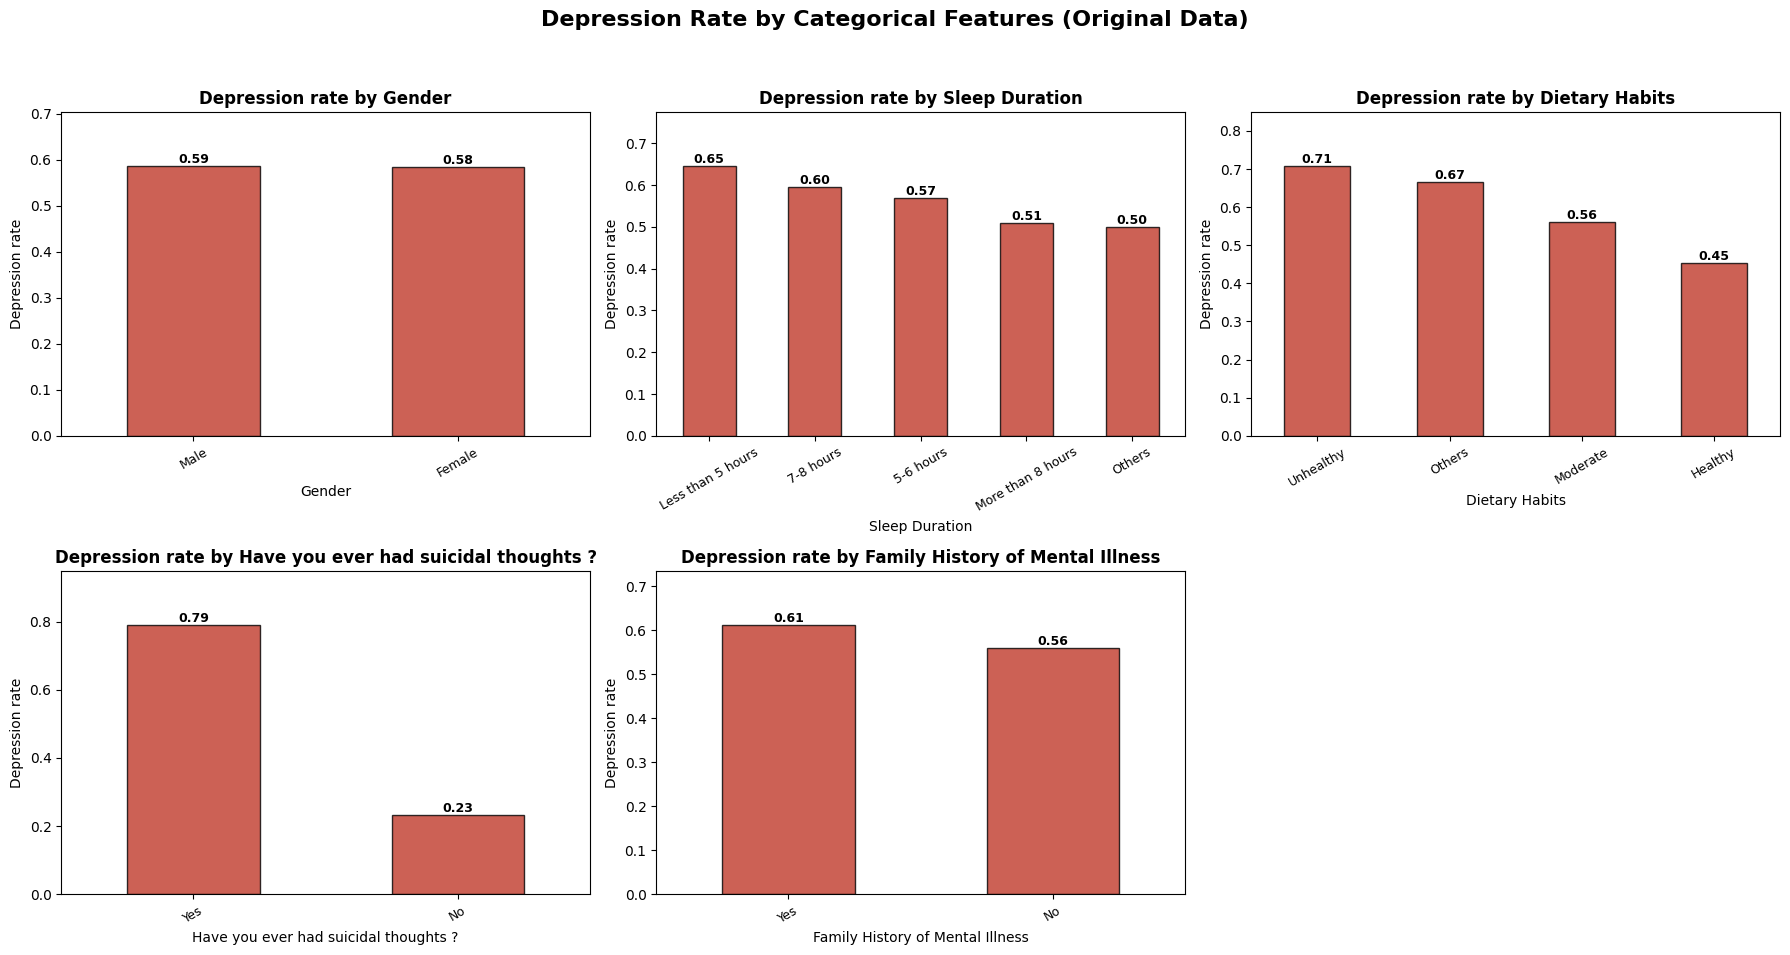

In [24]:
cat_eda = [c for c in ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'] if c in df_copy.columns]

n_cols = 3
n_rows = (len(cat_eda) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_eda):
    ax = axes[idx]
    rate = df_copy.groupby(col)['Depression'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#c0392b', edgecolor='black', alpha=0.8)
    ax.set_title(f'Depression rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Depression rate')
    ax.set_ylim(0, rate.max() * 1.2)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.bar_label(ax.containers[0], fmt='%.2f', fontsize=9, fontweight='bold')

for i in range(len(cat_eda), len(axes)):
    axes[i].axis('off')

plt.suptitle('Depression Rate by Categorical Features (Original Data)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

iv. Data Preprocessing

iv. i. Missing values

In [25]:
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())

print('Missing values after imputation:')
miss = df.isnull().sum()
print(miss[miss > 0] if miss[miss > 0].any() else 'None — all nulls resolved.')

Missing values after imputation:
None — all nulls resolved.


iv. ii. Categorical values

In [26]:
ohe_cols = [c for c in ['Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'] if c in df.columns]
print(f'Applying One-Hot Encoding to: {ohe_cols}')
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

Applying One-Hot Encoding to: ['Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


iv. iii. Unnecessary variables

In [27]:
drop_cols = [c for c in ['id', 'Job Satisfaction', 'Work Pressure', 'Gender', 'City', 'Profession', 'Degree'] if c in df.columns]
df.drop(drop_cols, axis=1, inplace=True)

df.columns = [re.sub(r'[\[\]<]', '_', col) for col in df.columns]

print(f'Final feature count: {df.shape[1] - 1}')
print(f'Final dataset shape: {df.shape}')

Final feature count: 15
Final dataset shape: (27901, 16)


v. Dataset Splitting

In [28]:
SEED = 42
X = df.drop('Depression', axis=1)
y = df['Depression']
object_cols = X.select_dtypes(include='object').columns
if len(object_cols) > 0:
    X = pd.get_dummies(X, columns=object_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train set : {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set  : {X_test.shape[0]}  rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Train default rate: {y_train.mean()*100:.1f}%')
print(f'Test  default rate: {y_test.mean()*100:.1f}%')
print('Stratification confirmed — class ratio preserved in both sets.')

Train set : 22320 rows  (80%)
Test set  : 5581  rows  (20%)
Train default rate: 58.5%
Test  default rate: 58.6%
Stratification confirmed — class ratio preserved in both sets.


vi. Model Training - Leakage free pipelines

In [29]:
start_time = time.time()
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def get_knn_pipeline(n_neighbors=5):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED)),
        ('knn',    KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1))
    ])

def get_dt_pipeline(max_depth=5, min_samples_leaf=10):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED)),
        ('dt',     DecisionTreeClassifier(
                       max_depth=max_depth,
                       min_samples_leaf=min_samples_leaf,
                       class_weight='balanced',
                       random_state=SEED))
    ])

def get_nb_pipeline(var_smoothing=1e-9):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED)),
        ('nb',     GaussianNB(var_smoothing=var_smoothing))
    ])

def get_lr_pipeline(C=1.0):
    return ImbPipeline([
        ('scaler', RobustScaler()),
        ('smote',  SMOTE(random_state=SEED)),
        ('lr',     LogisticRegression(penalty='l1', solver='liblinear', C=C,
                                      class_weight='balanced', max_iter=500, random_state=SEED))
    ])

def get_mlp_pipeline(hidden_size=64, alpha=0.001):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED)),
        ('mlp',    MLPClassifier(
                       hidden_layer_sizes=(hidden_size,),
                       alpha=alpha, max_iter=200, random_state=SEED,
                       early_stopping=True, validation_fraction=0.1))
    ])

end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')


Execution time: 0.01 seconds.


vi. a. Neural Network (MLP) — Optuna Tuning

In [30]:
start_time = time.time()
def mlp_obj(trial):
    hs = trial.suggest_categorical('hidden_size', [64, 128])
    alpha = trial.suggest_float('alpha', 1e-4, 1e-3, log=True)
    return cross_val_score(get_mlp_pipeline(hs, alpha), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

mlp_study = optuna.create_study(direction='maximize')
mlp_study.optimize(mlp_obj, n_trials=5)
print(f'Best MLP CV Accuracy: {mlp_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best MLP CV Accuracy: 0.8425

Execution time: 66.68 seconds.


vi. b. KNN — Optuna Hyperparameter Tuning

In [31]:
start_time = time.time()
def knn_obj(trial):
    k = trial.suggest_int('n_neighbors', 10, 20)
    return cross_val_score(get_knn_pipeline(k), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

knn_study = optuna.create_study(direction='maximize')
knn_study.optimize(knn_obj, n_trials=5)
print(f'Best KNN CV Accuracy: {knn_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best KNN CV Accuracy: 0.8214

Execution time: 90.16 seconds.


vi. c. Decision Tree — Optuna Hyperparameter Tuning

In [32]:
start_time = time.time()
def dt_obj(trial):
    max_depth = trial.suggest_int('max_depth', 3, 7)
    return cross_val_score(get_dt_pipeline(max_depth), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

dt_study = optuna.create_study(direction='maximize')
dt_study.optimize(dt_obj, n_trials=5)
print(f'Best DT CV Accuracy: {dt_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best DT CV Accuracy: 0.8281

Execution time: 21.72 seconds.


vi. d. Naive Bayes — Optuna Hyperparameter Tuning

In [33]:
start_time = time.time()
def nb_obj(trial):
    vs = trial.suggest_float('var_smoothing', 1e-9, 1e-5, log=True)
    return cross_val_score(get_nb_pipeline(vs), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

nb_study = optuna.create_study(direction='maximize')
nb_study.optimize(nb_obj, n_trials=5)
print(f'Best NB CV Accuracy: {nb_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best NB CV Accuracy: 0.8226

Execution time: 17.77 seconds.


vi. e. Logistic Regression (L1 + RobustScaler) — Optuna Tuning

In [34]:
start_time = time.time()
def lr_obj(trial):
    C = trial.suggest_float('C', 0.1, 5.0, log=True)
    return cross_val_score(get_lr_pipeline(C), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_obj, n_trials=5)
print(f'Best LR CV Accuracy: {lr_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best LR CV Accuracy: 0.8449

Execution time: 13.56 seconds.


vi. f. Balanced Random Forest — Optuna Tuning

In [35]:
start_time = time.time()
def brf_obj(trial):
    n_est = trial.suggest_int('n_estimators', 50, 150)
    return cross_val_score(BalancedRandomForestClassifier(n_estimators=n_est, random_state=SEED, n_jobs=-1),
                           X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

brf_study = optuna.create_study(direction='maximize')
brf_study.optimize(brf_obj, n_trials=5)
print(f'Best BRF CV Accuracy: {brf_study.best_value:.4f}')
end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Best BRF CV Accuracy: 0.8375

Execution time: 39.47 seconds.


vi. g. Threshold optimization function

In [36]:
start_time = time.time()
def oof_best_threshold(pipeline, X_tr, y_tr, cv):
    simple_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    oof_proba = cross_val_predict(pipeline, X_tr, y_tr, cv=simple_cv,
                                  method='predict_proba', n_jobs=-1)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_tr, (oof_proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')


Execution time: 0.00 seconds.


vi. h. Building and fitting all supervised final models

In [37]:
start_time = time.time()

# --- Neural Network ---
mlp_pipe = get_mlp_pipeline(**mlp_study.best_params)
mlp_t, _ = oof_best_threshold(get_mlp_pipeline(**mlp_study.best_params), X_train, y_train, CV)
mlp_pipe.fit(X_train, y_train)
mlp_prob = mlp_pipe.predict_proba(X_test)[:, 1]
mlp_pred = (mlp_prob >= mlp_t).astype(int)
print(f'Neural Net done    (threshold={mlp_t:.2f})')

# --- KNN ---
knn_pipe = get_knn_pipeline(**knn_study.best_params)
knn_t, _ = oof_best_threshold(get_knn_pipeline(**knn_study.best_params), X_train, y_train, CV)
knn_pipe.fit(X_train, y_train)
knn_prob = knn_pipe.predict_proba(X_test)[:, 1]
knn_pred = (knn_prob >= knn_t).astype(int)
print(f'KNN done       (threshold={knn_t:.2f})')

# --- Decision Tree ---
dt_pipe = get_dt_pipeline(**dt_study.best_params)
dt_t, _ = oof_best_threshold(get_dt_pipeline(**dt_study.best_params), X_train, y_train, CV)
dt_pipe.fit(X_train, y_train)
dt_prob = dt_pipe.predict_proba(X_test)[:, 1]
dt_pred = (dt_prob >= dt_t).astype(int)
print(f'Decision Tree done (threshold={dt_t:.2f})')

# --- Naive Bayes ---
nb_pipe = get_nb_pipeline(**nb_study.best_params)
nb_t, _ = oof_best_threshold(get_nb_pipeline(**nb_study.best_params), X_train, y_train, CV)
nb_pipe.fit(X_train, y_train)
nb_prob = nb_pipe.predict_proba(X_test)[:, 1]
nb_pred = (nb_prob >= nb_t).astype(int)
print(f'Naive Bayes done   (threshold={nb_t:.2f})')

# --- Logistic Regression ---
lr_pipe = CalibratedClassifierCV(get_lr_pipeline(**lr_study.best_params), method='isotonic', cv=5)
lr_t, _ = oof_best_threshold(CalibratedClassifierCV(get_lr_pipeline(**lr_study.best_params), method='isotonic', cv=5), X_train, y_train, CV)
lr_pipe.fit(X_train, y_train)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= lr_t).astype(int)
print(f'Logistic Reg done  (threshold={lr_t:.2f})')

# --- Balanced Random Forest ---
brf_params = {**brf_study.best_params,
              'random_state': SEED, 'n_jobs': -1,
              'replacement': True, 'sampling_strategy': 'auto'}
brf = BalancedRandomForestClassifier(**brf_params)
brf_t, _ = oof_best_threshold(BalancedRandomForestClassifier(**brf_params), X_train, y_train, CV)
brf.fit(X_train, y_train)
brf_prob = brf.predict_proba(X_test)[:, 1]
brf_pred = (brf_prob >= brf_t).astype(int)
print(f'Balanced RF done   (threshold={brf_t:.2f})')

end_time = time.time()
print(f'\nExecution time: {end_time - start_time:.2f} seconds.')

Neural Net done    (threshold=0.34)
KNN done       (threshold=0.28)
Decision Tree done (threshold=0.39)
Naive Bayes done   (threshold=0.23)
Logistic Reg done  (threshold=0.41)
Balanced RF done   (threshold=0.27)

Execution time: 122.22 seconds.


vii. Unsupervised Learning — K-Means Clustering

vii. a. Elbow method

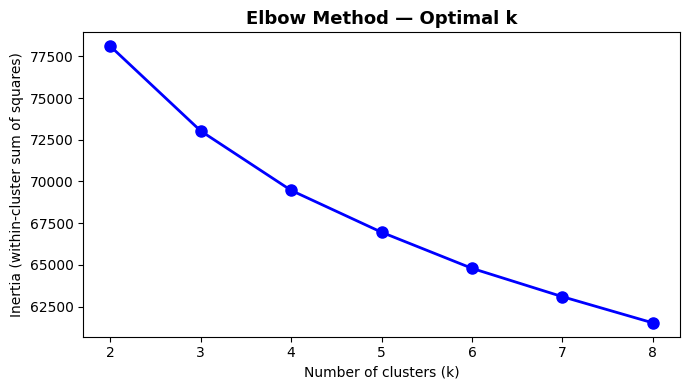

In [38]:
scaler_km  = RobustScaler()
X_train_sc = scaler_km.fit_transform(X_train)
X_test_sc  = scaler_km.transform(X_test)

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_train_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

vii. b. PCA for 2D visualization

Explained variance by 2 PCs: 28.2%
Cluster labels flipped for better alignment with true labels.


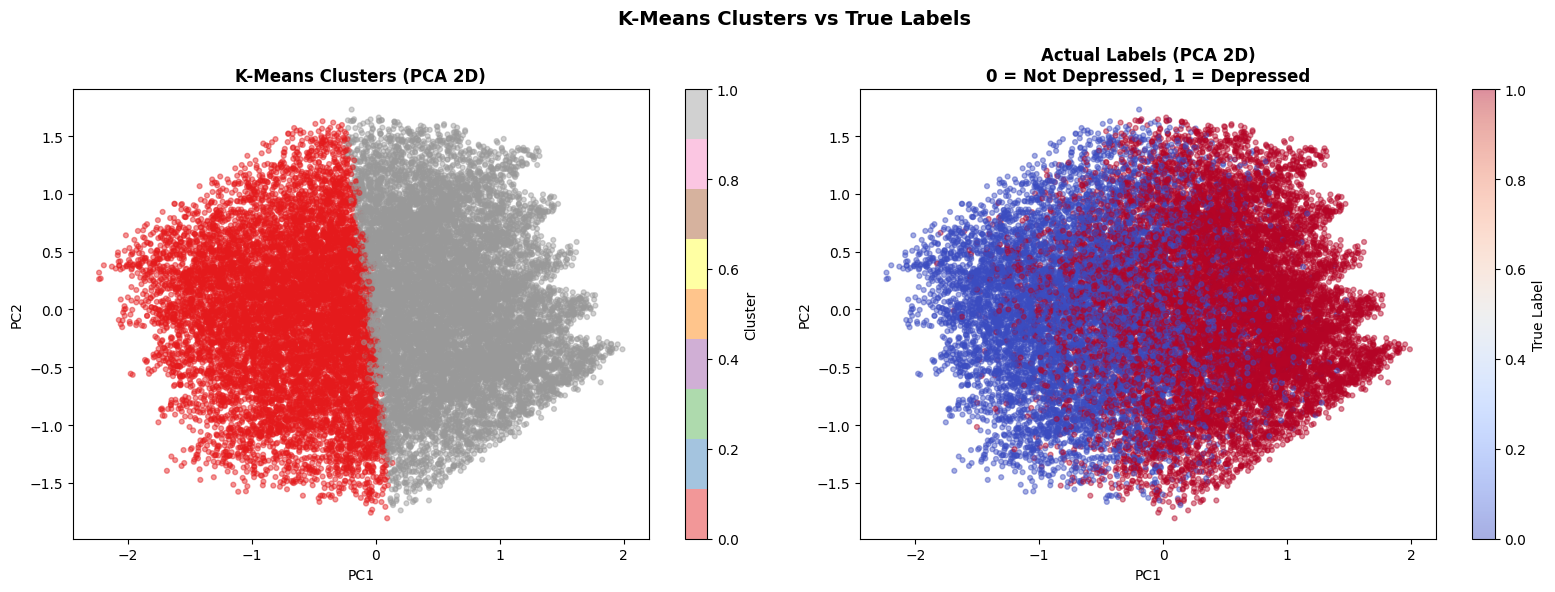

Adjusted Rand Index (clusters vs true labels): 0.3462
ARI near 0 = clusters do not align with defaults — confirms high irreducible noise.


In [39]:
pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_train_sc)
print(f'Explained variance by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

kmeans   = KMeans(n_clusters=2, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_train_sc)

# Auto-flip if needed
if accuracy_score(y_train, 1 - clusters) > accuracy_score(y_train, clusters):
    clusters = 1 - clusters
    print('Cluster labels flipped for better alignment with true labels.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap='Set1', alpha=0.45, s=12)
axes[0].set_title('K-Means Clusters (PCA 2D)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train.values,
                      cmap='coolwarm', alpha=0.45, s=12)
axes[1].set_title('Actual Labels (PCA 2D)\n0 = Not Depressed, 1 = Depressed',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[1], label='True Label')

plt.suptitle('K-Means Clusters vs True Labels', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

ari = adjusted_rand_score(y_train, clusters)
print(f'Adjusted Rand Index (clusters vs true labels): {ari:.4f}')
print('ARI near 0 = clusters do not align with defaults — confirms high irreducible noise.')

viii. Model Comparison Analysis

viii. a. Metrics Summary Table

In [40]:
model_entries = [
    ('Neural Network',    mlp_pred, mlp_prob,  mlp_t),
    ('KNN',               knn_pred, knn_prob,  knn_t),
    ('Decision Tree',     dt_pred,  dt_prob,   dt_t),
    ('Naive Bayes',       nb_pred,  nb_prob,   nb_t),
    ('Logistic Reg (L1)', lr_pred,  lr_prob,   lr_t),
    ('Balanced RF',       brf_pred, brf_prob,  brf_t),
]

km_test_clusters = kmeans.predict(X_test_sc)
if accuracy_score(y_test, 1 - km_test_clusters) > accuracy_score(y_test, km_test_clusters):
    km_test_pred = 1 - km_test_clusters
else:
    km_test_pred = km_test_clusters

results = {}
for name, pred, prob, thr in model_entries:
    results[name] = {
        'Threshold': round(thr, 2),
        'Accuracy':  round(accuracy_score(y_test, pred),  4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred),    4),
        'F1':        round(f1_score(y_test, pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_test, prob),   4),
    }

results['K-Means Clustering'] = {
    'Threshold': 0.50,
    'Accuracy':  round(accuracy_score(y_test, km_test_pred), 4),
    'Precision': round(precision_score(y_test, km_test_pred), 4),
    'Recall':    round(recall_score(y_test, km_test_pred), 4),
    'F1':        round(f1_score(y_test, km_test_pred), 4),
    'AUC-ROC':   0.5000
}

res_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print('=' * 75)
print('        FINAL MODEL COMPARISON TABLE (Supervised + Unsupervised)')
print('=' * 75)
print(res_df.to_string())
print(f'\nBest model: {res_df.index[0]}  (F1 = {res_df["F1"].iloc[0]:.4f})')

        FINAL MODEL COMPARISON TABLE (Supervised + Unsupervised)
                    Threshold  Accuracy  Precision  Recall      F1  AUC-ROC
Neural Network           0.34    0.8412     0.8344  0.9094  0.8703   0.9180
Logistic Reg (L1)        0.41    0.8387     0.8262  0.9177  0.8695   0.9189
Naive Bayes              0.23    0.8402     0.8392  0.8993  0.8682   0.9148
Balanced RF              0.27    0.8292     0.8176  0.9119  0.8621   0.9095
Decision Tree            0.39    0.8289     0.8237  0.9006  0.8604   0.8970
KNN                      0.28    0.8197     0.8068  0.9100  0.8553   0.8937
K-Means Clustering       0.50    0.7902     0.8482  0.7815  0.8135   0.5000

Best model: Neural Network  (F1 = 0.8703)


viii. b. Bar Charts — Accuracy & F1 (all models)

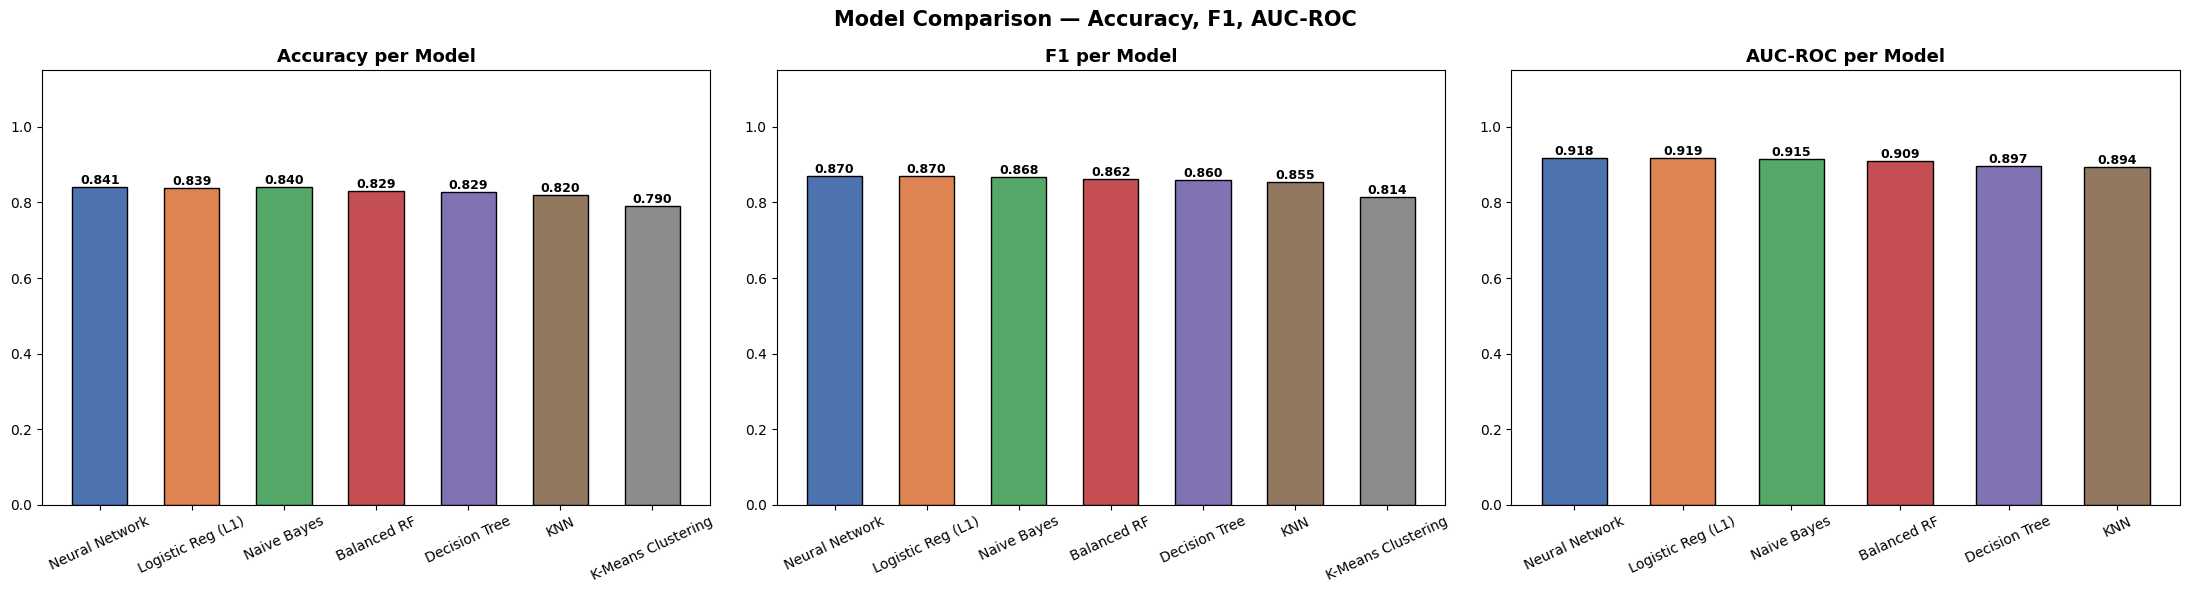

In [41]:
model_names = list(res_df.index)
bar_colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#8c8c8c']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    if metric == 'AUC-ROC':
        plot_models = [m for m in model_names if m != 'K-Means Clustering']
        plot_colors = [bar_colors[model_names.index(m)] for m in plot_models]
    else:
        plot_models = model_names
        plot_colors = bar_colors

    vals = [results[m][metric] for m in plot_models]
    bars = ax.bar(plot_models, vals, color=plot_colors, edgecolor='black', width=0.6)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric} per Model', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Model Comparison — Accuracy, F1, AUC-ROC', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

viii. c. Precision & Recall Comparison

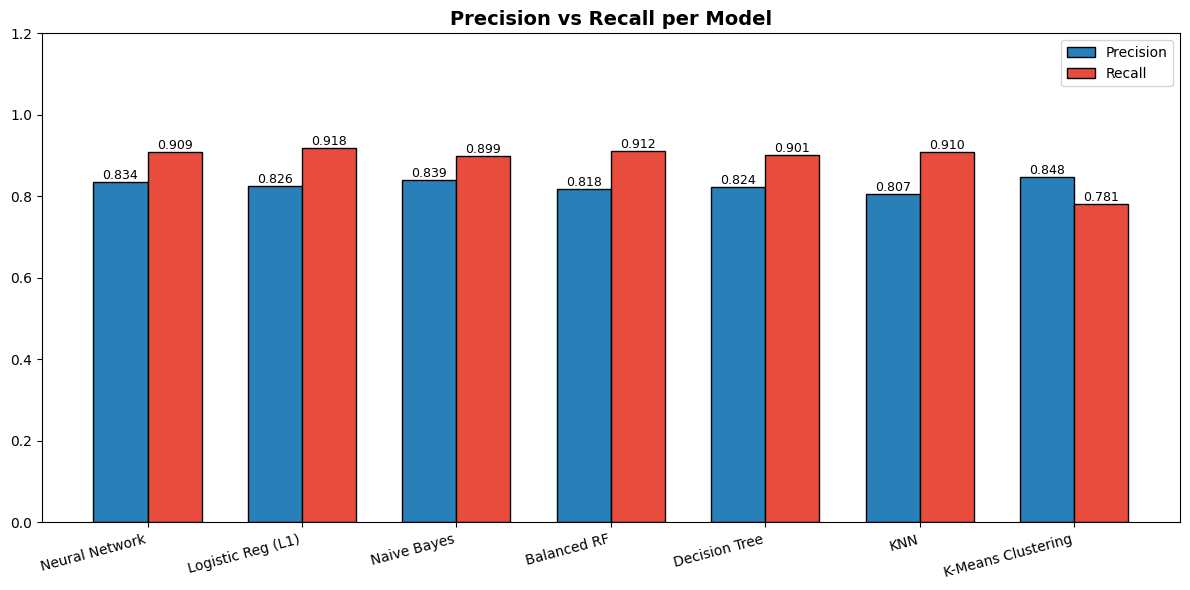

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
w = 0.35
prec_vals = [results[m]['Precision'] for m in model_names]
rec_vals  = [results[m]['Recall']    for m in model_names]

b1 = ax.bar(x - w/2, prec_vals, w, label='Precision', color='#2980b9', edgecolor='black')
b2 = ax.bar(x + w/2, rec_vals,  w, label='Recall',    color='#e74c3c', edgecolor='black')
ax.bar_label(b1, fmt='%.3f', fontsize=9)
ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_title('Precision vs Recall per Model', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

viii. d. Classification Reports (all models)

In [43]:
all_reports = model_entries + [('K-Means Clustering', km_test_pred, None, 0.50)]

for name, pred, prob, thr in all_reports:
    print(f'\n{"="*55}')
    threshold_str = f"{thr:.2f}" if name != "K-Means Clustering" else "N/A (Clustering)"
    print(f'  {name}  (threshold = {threshold_str})')
    print(f'{"="*55}')
    print(classification_report(y_test, pred, target_names=['Not Depressed', 'Depressed']))


  Neural Network  (threshold = 0.34)
               precision    recall  f1-score   support

Not Depressed       0.85      0.74      0.80      2313
    Depressed       0.83      0.91      0.87      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.83      0.83      5581
 weighted avg       0.84      0.84      0.84      5581


  KNN  (threshold = 0.28)
               precision    recall  f1-score   support

Not Depressed       0.84      0.69      0.76      2313
    Depressed       0.81      0.91      0.86      3268

     accuracy                           0.82      5581
    macro avg       0.83      0.80      0.81      5581
 weighted avg       0.82      0.82      0.82      5581


  Decision Tree  (threshold = 0.39)
               precision    recall  f1-score   support

Not Depressed       0.84      0.73      0.78      2313
    Depressed       0.82      0.90      0.86      3268

     accuracy                           0.83      5581
    macro 

viii. e. Confusion Matrices (all models)

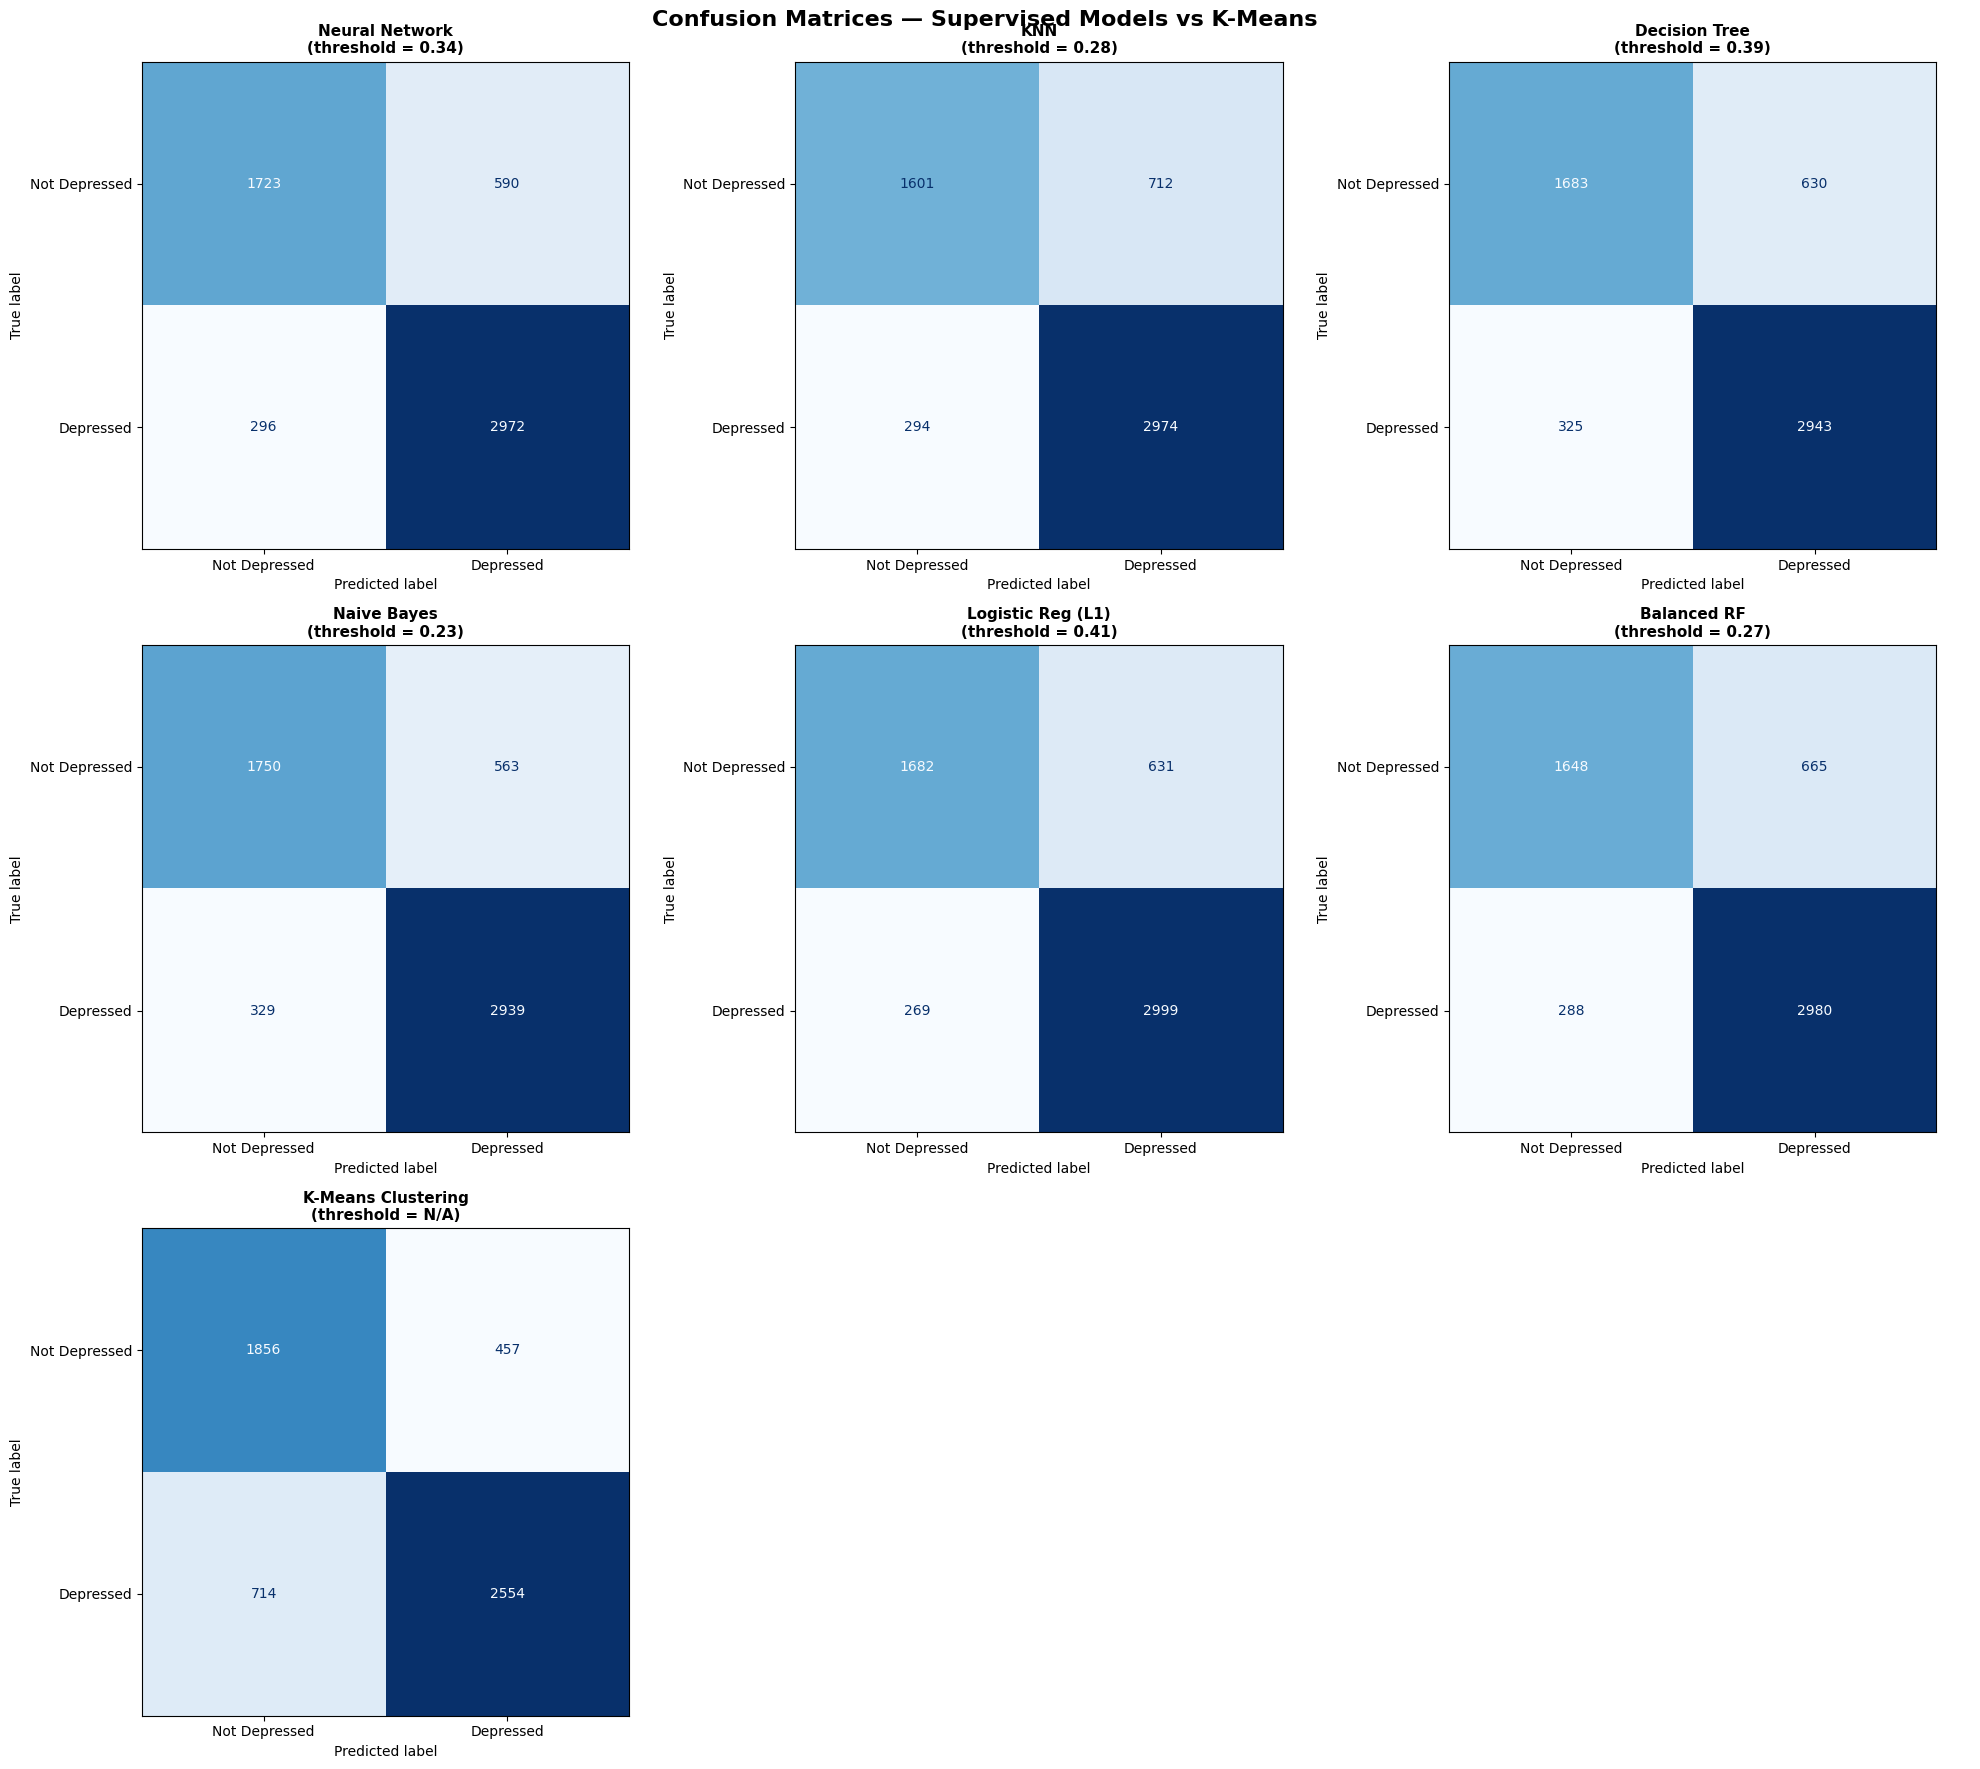

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

all_plot_models = model_entries + [('K-Means Clustering', km_test_pred, None, 0.50)]

for idx, (name, pred, prob, thr) in enumerate(all_plot_models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=axes[idx], cmap='Blues',
        colorbar=False, display_labels=['Not Depressed', 'Depressed'])

    threshold_str = f"{thr:.2f}" if name != "K-Means Clustering" else "N/A"
    axes[idx].set_title(f'{name}\n(threshold = {threshold_str})', fontsize=11, fontweight='bold')

for i in range(len(all_plot_models), len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices — Supervised Models vs K-Means', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

viii. f. ROC Curves + AUC Scores (all models)

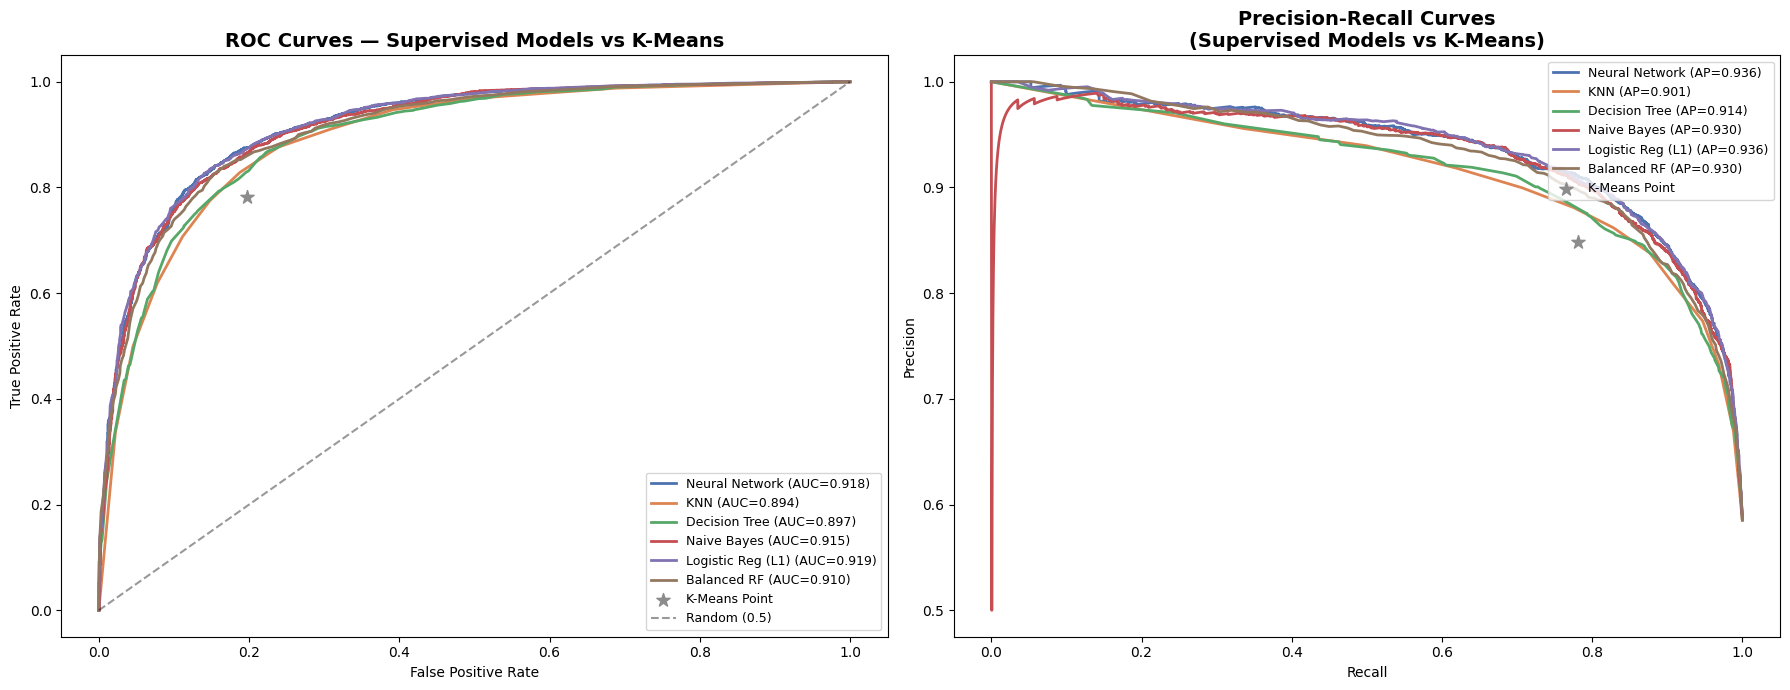

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors7 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#e74c3c']

# --- ROC Curves ---
for (name, pred, prob, thr), col in zip(model_entries, colors7):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col, linewidth=2)

# Add K-Means as a single point on ROC
km_fpr = 1 - recall_score(y_test, km_test_pred, pos_label=0)
km_tpr = recall_score(y_test, km_test_pred)
axes[0].scatter(km_fpr, km_tpr, color='#8c8c8c', s=100, marker='*', zorder=5, label='K-Means Point')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (0.5)')
axes[0].set_title('ROC Curves — Supervised Models vs K-Means', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)

# --- Precision-Recall Curves ---
for (name, pred, prob, thr), col in zip(model_entries, colors7):
    pr, re, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(re, pr, label=f'{name} (AP={ap:.3f})', color=col, linewidth=2)

# Add K-Means as a single point on PR
km_prec = precision_score(y_test, km_test_pred)
km_rec  = recall_score(y_test, km_test_pred)
axes[1].scatter(km_rec, km_prec, color='#8c8c8c', s=100, marker='*', zorder=5, label='K-Means Point')

axes[1].set_title('Precision-Recall Curves\n(Supervised Models vs K-Means)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

ix. Conclusion

In [46]:
print('=' * 65)
print('       FINAL RESULTS — CSE422 Student Depression Prediction')
print('=' * 65)
print(res_df.to_string())
print(f'\nBest model: {res_df.index[0]}  (F1 = {res_df["F1"].iloc[0]:.4f})')

       FINAL RESULTS — CSE422 Student Depression Prediction
                    Threshold  Accuracy  Precision  Recall      F1  AUC-ROC
Neural Network           0.34    0.8412     0.8344  0.9094  0.8703   0.9180
Logistic Reg (L1)        0.41    0.8387     0.8262  0.9177  0.8695   0.9189
Naive Bayes              0.23    0.8402     0.8392  0.8993  0.8682   0.9148
Balanced RF              0.27    0.8292     0.8176  0.9119  0.8621   0.9095
Decision Tree            0.39    0.8289     0.8237  0.9006  0.8604   0.8970
KNN                      0.28    0.8197     0.8068  0.9100  0.8553   0.8937
K-Means Clustering       0.50    0.7902     0.8482  0.7815  0.8135   0.5000

Best model: Neural Network  (F1 = 0.8703)
